# Job Market Intelligence System
# Step 1: Data Exploration

In [3]:
import pandas as pd
import numpy as np
df=pd.read_csv("/content/job_dataset.csv")
df.head()


,JobID,Title,ExperienceLevel,YearsOfExperience,Skills,Responsibilities,Keywords
0,NET-F-001,.NET Developer,Fresher,0-1,C#; VB.NET basics; .NET Framework; .NET Core f...,Assist in coding and debugging applications; L...,.NET; C#; ASP.NET MVC; Entity Framework; SQL S...
1,NET-F-002,.NET Developer,Fresher,0-1,C#; .NET Framework basics; ASP.NET; Razor; HTM...,Write simple C# programs under guidance; Suppo...,.NET; C#; ASP.NET MVC; Entity Framework; SQL S...
2,NET-F-003,.NET Developer,Fresher,0-1,C#; VB.NET basics; .NET Core; ASP.NET MVC; HTM...,Contribute to development of small modules; As...,.NET; C#; ASP.NET MVC; SQL Server; Entity Fram...
3,NET-F-004,.NET Developer,Fresher,0-1,C#; .NET Framework; ASP.NET basics; SQL Server...,Support in software design documentation; Assi...,.NET; C#; SQL Server; Entity Framework; ASP.NET
4,NET-F-005,.NET Developer,Fresher,0-1,C#; ASP.NET; MVC; Entity Framework basics; SQL...,Learn to design and build ASP.NET applications...,.NET; C#; ASP.NET MVC; Entity Framework; SQL S...


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   JobID              1068 non-null   object
 1   Title              1067 non-null   object
 2   ExperienceLevel    1068 non-null   object
 3   YearsOfExperience  1068 non-null   object
 4   Skills             1068 non-null   object
 5   Responsibilities   1068 non-null   object
 6   Keywords           1068 non-null   object
dtypes: object(7)
memory usage: 58.5+ KB


In [5]:
df.describe()

,JobID,Title,ExperienceLevel,YearsOfExperience,Skills,Responsibilities,Keywords
count,1068,1067,1068,1068,1068,1068,1068
unique,1038,218,11,110,969,1047,678
top,2,.NET Developer,Experienced,0-1,Salesforce; HubSpot; Predictive Analytics; Lea...,Lead product vision and strategy; Oversee road...,Unity; Unreal Engine; C#; ARKit; ARCore; 3D Gr...
freq,3,20,476,247,6,3,15


In [6]:
df.isnull().sum()
df.dropna(inplace=True)

In [7]:
df.isnull().sum()

,0
JobID,0
Title,0
ExperienceLevel,0
YearsOfExperience,0
Skills,0
Responsibilities,0
Keywords,0


In [8]:
df['Skills'] = df['Skills'].astype(str)

In [9]:
df['Skills_list'] = df['Skills'].apply(lambda x: x.split(';'))

In [10]:
from collections import Counter
import pandas as pd

all_skills = sum(df['Skills_list'], [])
skill_counts = Counter(all_skills) # Define skill_counts as the Counter object

In [11]:
import pandas as pd

skill_df = pd.DataFrame(skill_counts.items(), columns=['Skill','Count'])
skill_df = skill_df.sort_values(by='Count', ascending=False)

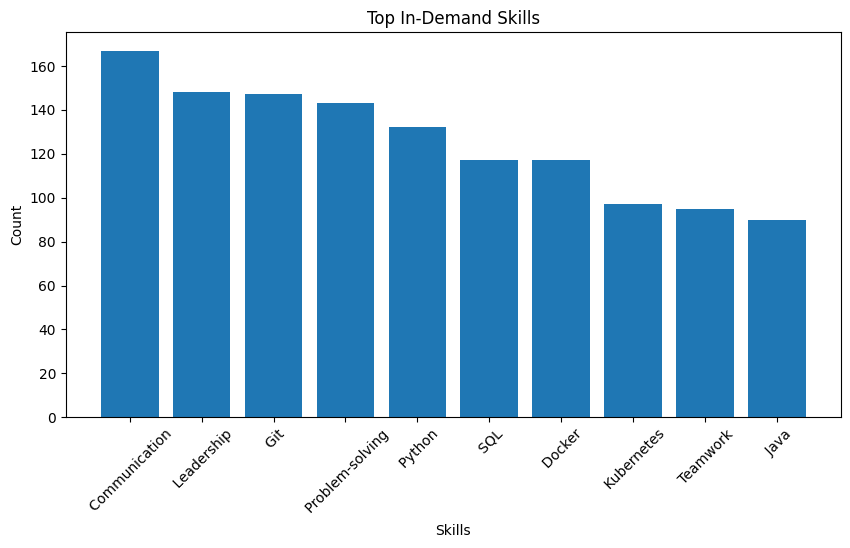

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(skill_df['Skill'][:10], skill_df['Count'][:10],)
plt.xlabel("Skills")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.title("Top In-Demand Skills")
plt.show()

“I processed structured job data by converting skill strings into lists, then analyzed frequency distribution to identify the most in-demand skills across job roles.”

2) ROLE-WISE SKILL ANALYSIS

In [13]:
df['Title'].value_counts()

,count
Title,
.NET Developer,20
AI Prompt Engineer,20
AR/VR Developer,20
Business Analyst,20
Data Engineer,20
...,...
Senior Interaction Designer,1
UX Consultant,1
UX Strategist,1


.NET Developer

*    C# appears in almost all postings
*   SQL Server is highly demanded
*   ASP.NET is a core requirement






In [14]:
net_df = df[df['Title'] == '.NET Developer']
net_df[['Title', 'Skills']]

,Title,Skills
0,.NET Developer,C#; VB.NET basics; .NET Framework; .NET Core f...
1,.NET Developer,C#; .NET Framework basics; ASP.NET; Razor; HTM...
2,.NET Developer,C#; VB.NET basics; .NET Core; ASP.NET MVC; HTM...
3,.NET Developer,C#; .NET Framework; ASP.NET basics; SQL Server...
4,.NET Developer,C#; ASP.NET; MVC; Entity Framework basics; SQL...
5,.NET Developer,C#; .NET Framework; ASP.NET; Razor; SQL Server...
6,.NET Developer,C#; VB.NET; .NET Core basics; ASP.NET MVC; HTM...
7,.NET Developer,C#; .NET Framework basics; ASP.NET MVC; Entity...
8,.NET Developer,C#; .NET Framework; ASP.NET; HTML; CSS; SQL Se...
9,.NET Developer,C#; ASP.NET MVC; .NET Core basics; Entity Fram...


In [15]:
from collections import Counter

net_skills = sum(net_df['Skills_list'], [])

net_skill_counts = Counter(net_skills)

net_skill_df = pd.DataFrame(
    net_skill_counts.items(),
    columns=['Skill', 'Count']
)

net_skill_df = net_skill_df.sort_values(
    by='Count',
    ascending=False
)

net_skill_df.head(10)

,Skill,Count
0,C#,20
9,SQL Server,15
19,ASP.NET MVC,10
7,CSS,7
6,HTML,7
18,.NET Core,7
26,Azure,5
10,Entity Framework basics,5
4,ASP.NET,5
13,Git,4


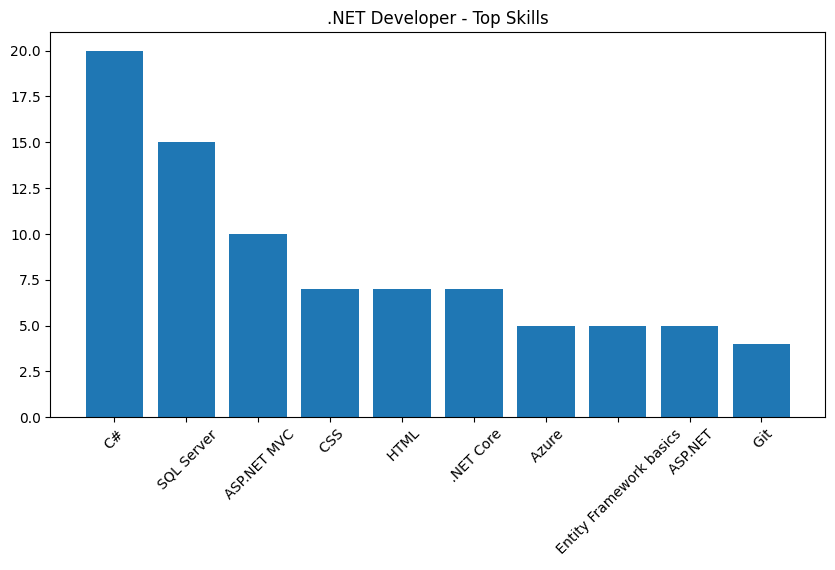

In [16]:
import matplotlib.pyplot as plt

top10 = net_skill_df.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10['Skill'], top10['Count'])
plt.xticks(rotation=45)
plt.title('.NET Developer - Top Skills')
plt.show()

Business Analyst

In [17]:
ba_df = df[df['Title'] == 'Business Analyst']

ba_skills = sum(ba_df['Skills_list'], [])

from collections import Counter

ba_skill_counts = Counter(ba_skills)

pd.DataFrame(
    ba_skill_counts.items(),
    columns=['Skill','Count']
).sort_values('Count', ascending=False).head(10)

,Skill,Count
12,Tableau,15
13,Power BI,15
11,SQL,12
1,Excel,10
5,Requirement gathering,7
39,Agile methodology,7
0,Data analysis,6
8,Communication,5
9,Problem-solving,5
25,Strategic planning,5


In [18]:
de_df = df[df['Title'] == 'Data Engineer']

de_skills = sum(de_df['Skills_list'], [])

de_skill_counts = Counter(de_skills)

pd.DataFrame(
    de_skill_counts.items(),
    columns=['Skill','Count']
).sort_values('Count', ascending=False).head(10)

,Skill,Count
0,Python,17
2,SQL,13
4,MongoDB,11
33,Airflow,9
32,Kafka,7
3,PostgreSQL,6
16,Java,6
37,Snowflake,5
5,Hadoop Basics,4
1,Java Basics,4


Comparing Data Engineer vs Business Analyst

In [19]:
import pandas as pd

# Create a DataFrame for Business Analyst skills from the existing Counter object
ba_skills_df = pd.DataFrame(
    ba_skill_counts.items(),
    columns=['Skill', 'BA_Count']
).sort_values('BA_Count', ascending=False)

# Create a DataFrame for Data Engineer skills from the existing Counter object
de_skills_df = pd.DataFrame(
    de_skill_counts.items(),
    columns=['Skill', 'DE_Count']
).sort_values('DE_Count', ascending=False)

# Display the top skills for each role
print("Top 10 Business Analyst Skills:")
print(ba_skills_df.head(10))
print("\nTop 10 Data Engineer Skills:")
print(de_skills_df.head(10))

# Optionally, merge them for a combined comparison
compare_skills_df = pd.merge(
    ba_skills_df.set_index('Skill'),
    de_skills_df.set_index('Skill'),
    left_index=True,
    right_index=True,
    how='outer'
).fillna(0).astype(int)

print("\nCombined Top Skills Comparison (BA vs DE):")
print(compare_skills_df.sort_values(by=['BA_Count', 'DE_Count'], ascending=False).head(50))

Top 10 Business Analyst Skills:
                     Skill  BA_Count
12                 Tableau        15
13                Power BI        15
11                     SQL        12
1                    Excel        10
5    Requirement gathering         7
39       Agile methodology         7
0            Data analysis         6
8            Communication         5
9          Problem-solving         5
25      Strategic planning         5

Top 10 Data Engineer Skills:
             Skill  DE_Count
0           Python        17
2              SQL        13
4          MongoDB        11
33         Airflow         9
32           Kafka         7
3       PostgreSQL         6
16            Java         6
37       Snowflake         5
5    Hadoop Basics         4
1      Java Basics         4

Combined Top Skills Comparison (BA vs DE):
                                BA_Count  DE_Count
Skill                                             
 Power BI                             15         0
 Tableau       

Business Analysts focus more on business communication and reporting, while Data Engineers focus on data pipelines and big data technologies.

Now focusing on Experience

In [20]:
df['ExperienceLevel'].value_counts()

,count
ExperienceLevel,
Experienced,476
Fresher,363
Entry-Level,66
Senior-Level,65
Mid-Level,60
Senior,15
Lead,7
Junior,5
Mid-level,5


In [21]:
df['ExperienceLevel'].unique()

array(['Fresher', 'Experienced', 'Entry-Level', 'Mid-Senior Level',
       'Senior-Level', 'Mid-Level', 'Mid-Senior', 'Senior', 'Junior',
       'Mid-level', 'Lead'], dtype=object)

In [22]:
#MAPPING
experience_mapping = {
    'Fresher': 'Fresher',
    'Entry-Level': 'Fresher',
    'Junior': 'Fresher',

    'Mid-Level': 'Mid',
    'Mid-level': 'Mid',
    'Mid-Senior': 'Mid',
    'Mid-Senior Level': 'Mid',

    'Experienced': 'Experienced',

    'Senior': 'Senior',
    'Senior-Level': 'Senior',

    'Lead': 'Lead'
}

In [23]:
df['Experience_Clean'] = df['ExperienceLevel'].map(experience_mapping)

In [24]:
df['Experience_Clean'].value_counts()

,count
Experience_Clean,
Experienced,476
Fresher,434
Senior,80
Mid,70
Lead,7


In [25]:
fresher_df = df[df['Experience_Clean'] == 'Fresher']

In [26]:
fresher_skills = sum(fresher_df['Skills_list'], [])


In [27]:
from collections import Counter
Counter(fresher_skills).most_common(10)

[(' Communication', 136),
 (' Problem-solving', 95),
 (' Teamwork', 95),
 (' Git', 94),
 (' Adaptability', 62),
 (' Python basics', 59),
 ('Python basics', 50),
 (' Python', 49),
 ('Python', 44),
 (' JavaScript basics', 41)]

In [28]:
senior_df = df[df['Experience_Clean'] == 'Senior']

senior_skills = sum(senior_df['Skills_list'], [])

Counter(senior_skills).most_common(10)

[(' R', 32),
 (' Spark', 27),
 (' Hadoop', 27),
 (' Power BI', 22),
 (' Looker', 22),
 ('Python', 20),
 (' CI/CD', 20),
 (' Tableau', 20),
 (' Snowflake', 20),
 (' Kubernetes', 19)]

In [29]:
from collections import Counter
import pandas as pd

def top_skills_by_level(level, top_n=10):

    temp_df = df[df['Experience_Clean'] == level]

    skills = sum(temp_df['Skills_list'], [])

    skill_counts = Counter(skills)

    return pd.DataFrame(
        skill_counts.items(),
        columns=['Skill','Count']
    ).sort_values(
        by='Count',
        ascending=False
    ).head(top_n)

In [30]:
top_skills_by_level('Fresher')

,Skill,Count
53,Communication,136
60,Teamwork,95
59,Problem-solving,95
13,Git,94
147,Adaptability,62
112,Python basics,59
43,Python basics,50
96,Python,49
23,Python,44
8,JavaScript basics,41


In [31]:
top_skills_by_level('Mid')

,Skill,Count
29,Tableau,11
59,Collaboration,10
42,SEO optimization,8
148,Data Analysis,8
144,Scheduling,8
3,R,8
224,AI Writing Tools,7
216,Editing,7
215,Technical Writing,7
44,Editing and proofreading,7


In [32]:
top_skills_by_level('Senior')

,Skill,Count
3,R,32
19,Spark,27
20,Hadoop,27
36,Looker,22
34,Power BI,22
33,Tableau,20
17,CI/CD,20
0,Python,20
39,Snowflake,20
37,SQL,19


In [33]:
top_skills_by_level('Lead')

,Skill,Count
0,Python expert,7
1,JavaScript expert,7
2,Ruby advanced,7
4,AI coding assistant mastery,7
5,Prompt engineering expert,7
6,Debugging AI outputs,7
8,Mentoring,7
7,Project leadership,7
9,Team management,7
11,Strategic planning,7


In [34]:
fresher_top = top_skills_by_level('Fresher')
mid_top = top_skills_by_level('Mid')
senior_top = top_skills_by_level('Senior')
lead_top = top_skills_by_level('Lead')

In [35]:
levels = ['Fresher','Mid','Senior','Lead']

for level in levels:
    print(level)
    print(top_skills_by_level(level).head(5))
    print('-'*50)

Fresher
                Skill  Count
53      Communication    136
60           Teamwork     95
59    Problem-solving     95
13                Git     94
147      Adaptability     62
--------------------------------------------------
Mid
                 Skill  Count
29             Tableau     11
59       Collaboration     10
42    SEO optimization      8
148      Data Analysis      8
144         Scheduling      8
--------------------------------------------------
Senior
        Skill  Count
3           R     32
19      Spark     27
20     Hadoop     27
36     Looker     22
34   Power BI     22
--------------------------------------------------
Lead
                          Skill  Count
0                 Python expert      7
1             JavaScript expert      7
2                 Ruby advanced      7
4   AI coding assistant mastery      7
5     Prompt engineering expert      7
--------------------------------------------------


In [36]:
top_skills_by_level('Fresher')
top_skills_by_level('Mid')
top_skills_by_level('Senior')

,Skill,Count
3,R,32
19,Spark,27
20,Hadoop,27
36,Looker,22
34,Power BI,22
33,Tableau,20
17,CI/CD,20
0,Python,20
39,Snowflake,20
37,SQL,19


In [37]:
levels = ['Fresher', 'Mid', 'Experienced', 'Senior', 'Lead']

for level in levels:
    print(f"\n===== {level} =====")

    temp = df[df['Experience_Clean'] == level]

    skills = sum(temp['Skills_list'], [])

    top_skills = Counter(skills).most_common(10)

    print(top_skills)


===== Fresher =====
[(' Communication', 136), (' Problem-solving', 95), (' Teamwork', 95), (' Git', 94), (' Adaptability', 62), (' Python basics', 59), ('Python basics', 50), (' Python', 49), ('Python', 44), (' JavaScript basics', 41)]

===== Mid =====
[(' Tableau', 11), (' Collaboration', 10), (' R', 8), (' SEO optimization', 8), (' Scheduling', 8), (' Data Analysis', 8), (' SQL', 7), (' Editing and proofreading', 7), (' Illustrator', 7), (' InDesign', 7)]

===== Experienced =====
[(' Leadership', 148), (' Project management', 84), (' Docker', 83), (' Kubernetes', 68), (' CI/CD', 67), (' Node.js', 61), (' Python', 57), (' AWS', 54), (' SQL', 50), (' Azure', 48)]

===== Senior =====
[(' R', 32), (' Spark', 27), (' Hadoop', 27), (' Power BI', 22), (' Looker', 22), ('Python', 20), (' CI/CD', 20), (' Tableau', 20), (' Snowflake', 20), (' Kubernetes', 19)]

===== Lead =====
[('Python expert', 7), (' JavaScript expert', 7), (' Ruby advanced', 7), (' AI coding assistant mastery', 7), (' Pro

In [38]:
from collections import Counter

def get_role_skills(role, top_n=10):
    role_df = df[df['Title'] == role]
    skills = sum(role_df['Skills_list'], [])
    skill_counts = Counter(skills)

    top_skills = [skill for skill, count in skill_counts.most_common(top_n)]
    return top_skills

In [39]:
def clean_user_skills(user_skills):
    return [skill.strip() for skill in user_skills]

In [40]:
def skill_gap_analyzer(user_skills, target_role):

    role_skills = get_role_skills(target_role)

    user_skills = clean_user_skills(user_skills)

    have = []
    missing = []

    for skill in role_skills:
        if skill in user_skills:
            have.append(skill)
        else:
            missing.append(skill)

    match_score = len(have) / len(role_skills) * 100

    return {
        "role_required_skills": role_skills,
        "matched_skills": have,
        "missing_skills": missing,
        "match_score": round(match_score, 2)
    }

In [41]:
user_skills = ["SQL", "Python", "Excel"]

result = skill_gap_analyzer(user_skills, "Data Engineer")

result

{'role_required_skills': ['Python',
  ' SQL',
  ' MongoDB',
  ' Airflow',
  ' Kafka',
  ' PostgreSQL',
  ' Java',
  ' Snowflake',
  ' Java Basics',
  ' Hadoop Basics'],
 'matched_skills': ['Python'],
 'missing_skills': [' SQL',
  ' MongoDB',
  ' Airflow',
  ' Kafka',
  ' PostgreSQL',
  ' Java',
  ' Snowflake',
  ' Java Basics',
  ' Hadoop Basics'],
 'match_score': 10.0}

In [42]:
def learning_path(missing_skills):

    roadmap = {
        "Spark": "Learn PySpark basics + distributed computing",
        "Hadoop": "Understand HDFS + MapReduce",
        "Snowflake": "Cloud data warehouse concepts",
        "Airflow": "Workflow orchestration basics",
        "Docker": "Containerization fundamentals"
    }

    return {skill: roadmap.get(skill, "Learn fundamentals") for skill in missing_skills}

In [43]:
result["learning_path"] = learning_path(result["missing_skills"])
result

{'role_required_skills': ['Python',
  ' SQL',
  ' MongoDB',
  ' Airflow',
  ' Kafka',
  ' PostgreSQL',
  ' Java',
  ' Snowflake',
  ' Java Basics',
  ' Hadoop Basics'],
 'matched_skills': ['Python'],
 'missing_skills': [' SQL',
  ' MongoDB',
  ' Airflow',
  ' Kafka',
  ' PostgreSQL',
  ' Java',
  ' Snowflake',
  ' Java Basics',
  ' Hadoop Basics'],
 'match_score': 10.0,
 'learning_path': {' SQL': 'Learn fundamentals',
  ' MongoDB': 'Learn fundamentals',
  ' Airflow': 'Learn fundamentals',
  ' Kafka': 'Learn fundamentals',
  ' PostgreSQL': 'Learn fundamentals',
  ' Java': 'Learn fundamentals',
  ' Snowflake': 'Learn fundamentals',
  ' Java Basics': 'Learn fundamentals',
  ' Hadoop Basics': 'Learn fundamentals'}}

In [44]:
df.to_csv("cleaned_jobs.csv", index=False)

In [45]:
import os

os.listdir()

['.config', 'job_dataset.csv', 'cleaned_jobs.csv', 'sample_data']